# Chapter 3. Processes with Jumps

이 노트북은 Chapter 3, **Processes with Jumps**에 등장하는 Python Listing을 정리한 것입니다.

포함한 Python 코드는 다음 9개입니다.

- Listing 3.2: Poisson process paths
- Listing 3.4: Poisson process generation
- Listing 3.6: Poisson process path from jump times
- Listing 3.8: Poisson process path from jump times
- Listing 3.10: Compensated Poisson process
- Listing 3.12: Compound Poisson process simulation
- Listing 3.14: Compound Poisson with Gaussian jumps
- Listing 3.16: Compensated compound Poisson process
- Listing 3.18: Simulation of ruin probability

## 공통 설정

아래 셀은 모든 Listing에서 공통으로 쓰는 라이브러리와 그래프 기본값입니다. 난수 생성기 `rng`에 seed를 고정해, 다시 실행해도 비슷한 형태의 그림을 확인할 수 있게 했습니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy import stats
except ImportError:
    stats = None

rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 120,
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 3.1 The Poisson Process

Poisson process `N_t`는 시간 `t`까지 발생한 점프 또는 사건의 개수를 세는 counting process입니다. 강도 `lambda`가 클수록 같은 시간 안에 더 많은 점프가 발생합니다.

### Listing 3.2. Poisson process paths

점프 시각이 이미 주어졌을 때 `N_t`를 계단 함수로 그립니다. 점프가 일어날 때마다 process 값이 1씩 증가합니다.

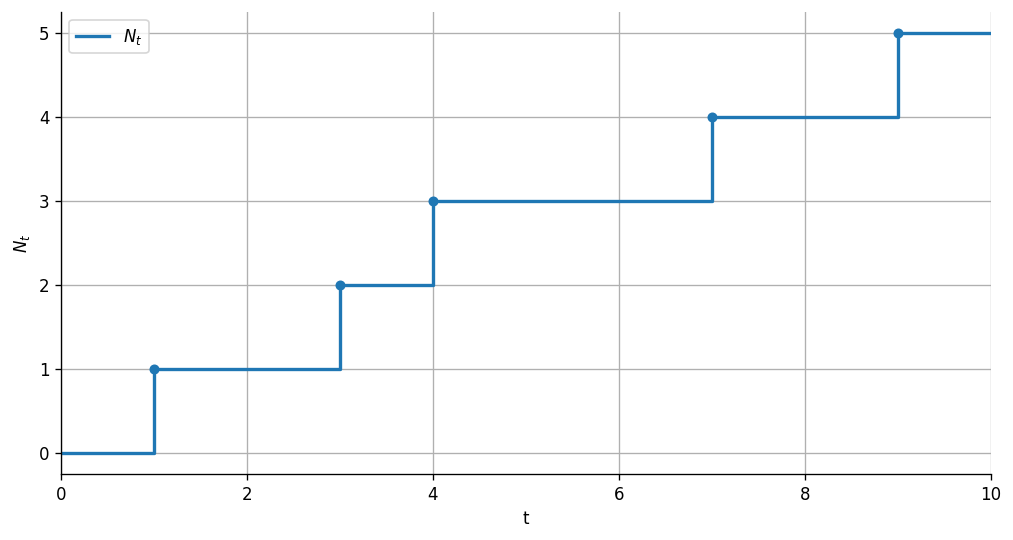

In [2]:
T = 10
jump_times = np.array([1, 3, 4, 7, 9], dtype=float)

plot_times = np.r_[0, jump_times, T]
process_values = np.r_[0, np.arange(1, len(jump_times) + 1), len(jump_times)]

fig, ax = plt.subplots()
ax.step(plot_times, process_values, where="post", color="tab:blue", linewidth=2, label=r"$N_t$")
ax.scatter(jump_times, np.arange(1, len(jump_times) + 1), color="tab:blue", s=25, zorder=3)
ax.set_xlim(0, T)
ax.set_xlabel("t")
ax.set_ylabel(r"$N_t$")
ax.legend()
plt.show()

### Listing 3.4. Poisson process generation

짧은 시간 간격 `h`마다 점프가 발생할 확률을 `lambda * h`로 근사해 Poisson process 경로를 생성합니다. `h`가 작을수록 연속시간 Poisson process에 가까워집니다.

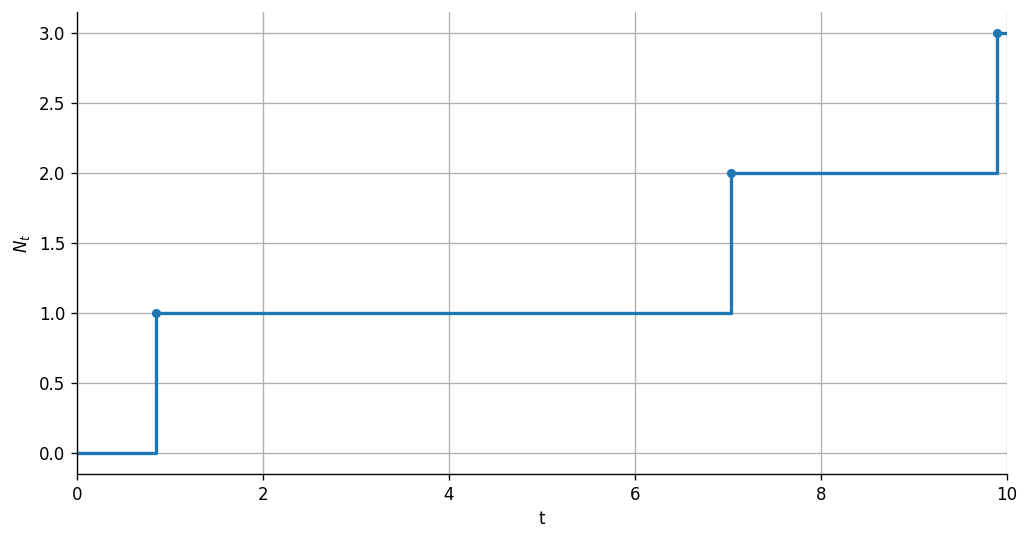

In [3]:
lbd = 0.6
T = 10
n_grid = int(1000 * lbd)
h = T / n_grid

time_grid = np.linspace(0, T - h, n_grid)
jump_mask = rng.random(n_grid) < lbd * h
jump_times = time_grid[jump_mask]

plot_times = np.r_[0, jump_times, T]
process_values = np.r_[0, np.arange(1, len(jump_times) + 1), len(jump_times)]

fig, ax = plt.subplots()
ax.step(plot_times, process_values, where="post", color="tab:blue", linewidth=2)
ax.scatter(jump_times, np.arange(1, len(jump_times) + 1), color="tab:blue", s=20, zorder=3)
ax.set_xlim(0, T)
ax.set_xlabel("t")
ax.set_ylabel(r"$N_t$")
plt.show()

### Listing 3.6. Poisson process path from jump times

Poisson process의 점프 간 대기시간은 exponential distribution을 따릅니다. 따라서 exponential 난수를 누적합하면 점프 시각 `T_n`을 만들 수 있습니다.

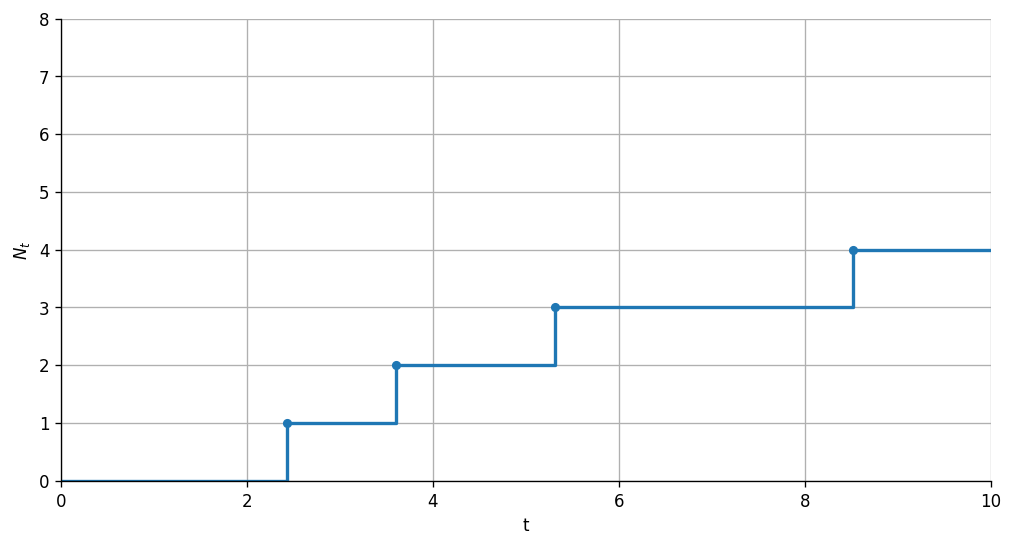

In [4]:
lbd = 0.6
T = 10

interarrival_times = rng.exponential(scale=1 / lbd, size=10_000)
all_jump_times = np.cumsum(interarrival_times)
jump_times = all_jump_times[all_jump_times <= T]

plot_times = np.r_[0, jump_times, T]
process_values = np.r_[0, np.arange(1, len(jump_times) + 1), len(jump_times)]

fig, ax = plt.subplots()
ax.step(plot_times, process_values, where="post", color="tab:blue", linewidth=2)
ax.scatter(jump_times, np.arange(1, len(jump_times) + 1), color="tab:blue", s=20, zorder=3)
ax.set_xlim(0, T)
ax.set_ylim(0, max(8, len(jump_times) + 1))
ax.set_xlabel("t")
ax.set_ylabel(r"$N_t$")
plt.show()

### Listing 3.8. Poisson process path from jump times

조건부로 `N_T = n`이 주어졌다면, `[0, T]` 안의 점프 시각은 uniform distribution에서 뽑은 뒤 정렬해서 만들 수 있습니다. 여기서는 먼저 `N_T`를 Poisson 분포에서 뽑고, 그 개수만큼 uniform 점프 시각을 생성합니다.

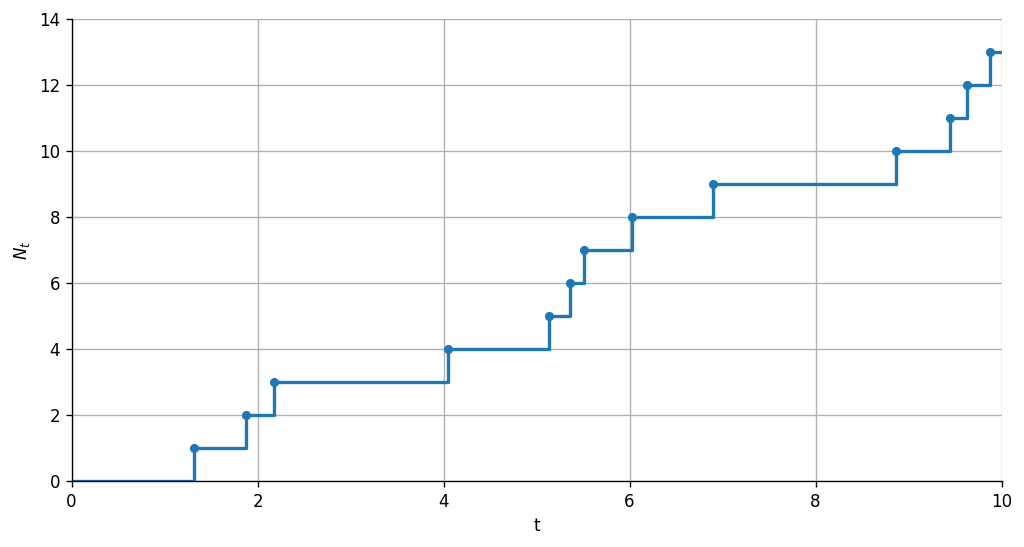

In [5]:
lbd = 0.6
T = 10

n_jumps = rng.poisson(lbd * T)
jump_times = np.sort(rng.uniform(0, T, size=n_jumps))

plot_times = np.r_[0, jump_times, T]
process_values = np.r_[0, np.arange(1, len(jump_times) + 1), len(jump_times)]

fig, ax = plt.subplots()
ax.step(plot_times, process_values, where="post", color="tab:blue", linewidth=2)
ax.scatter(jump_times, np.arange(1, len(jump_times) + 1), color="tab:blue", s=20, zorder=3)
ax.set_xlim(0, T)
ax.set_ylim(0, max(8, len(jump_times) + 1))
ax.set_xlabel("t")
ax.set_ylabel(r"$N_t$")
plt.show()

### Listing 3.10. Compensated Poisson process

`N_t`의 평균은 `lambda * t`입니다. 따라서 `N_t - lambda * t`는 평균 흐름을 제거한 compensated Poisson process이며, 0 주변에서 위아래로 움직이는 형태가 됩니다.

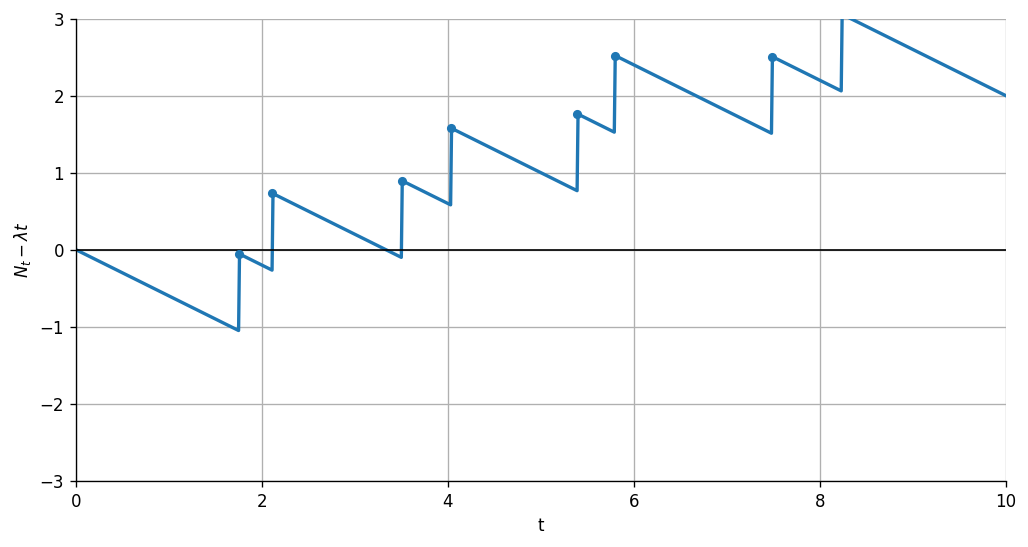

In [6]:
lam = 0.6
T = 10

enough_jumps = int(10 * lam * T) + 2_000
interarrival_times = rng.exponential(scale=1 / lam, size=enough_jumps)
jump_times = np.cumsum(interarrival_times)
jump_times = jump_times[jump_times <= T]

t = np.linspace(0, T, 1_001)
N_t = np.searchsorted(jump_times, t, side="right")
compensated = N_t - lam * t

jump_levels = np.searchsorted(jump_times, jump_times, side="right") - lam * jump_times

fig, ax = plt.subplots()
ax.plot(t, compensated, color="tab:blue", linewidth=2)
ax.scatter(jump_times, jump_levels, color="tab:blue", s=20, zorder=3)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlim(0, T)
ax.set_ylim(-3, 3)
ax.set_xlabel("t")
ax.set_ylabel(r"$N_t - \lambda t$")
plt.show()

## 3.2 Compound Poisson Process

Compound Poisson process는 점프 횟수뿐 아니라 각 점프 크기 `Z_k`까지 더해 만든 process입니다.

\[
Y_t = \sum_{k=1}^{N_t} Z_k
\]

보험 청구액, 손실 누적액처럼 사건이 발생할 때마다 금액이 더해지는 상황을 표현할 때 자연스럽게 쓰입니다.

### Listing 3.12. Compound Poisson process simulation

점프 시각은 exponential 대기시간으로 만들고, 각 점프 크기는 exponential distribution에서 생성합니다. 결과 process `Y_t`는 점프가 발생할 때마다 양의 크기만큼 증가합니다.

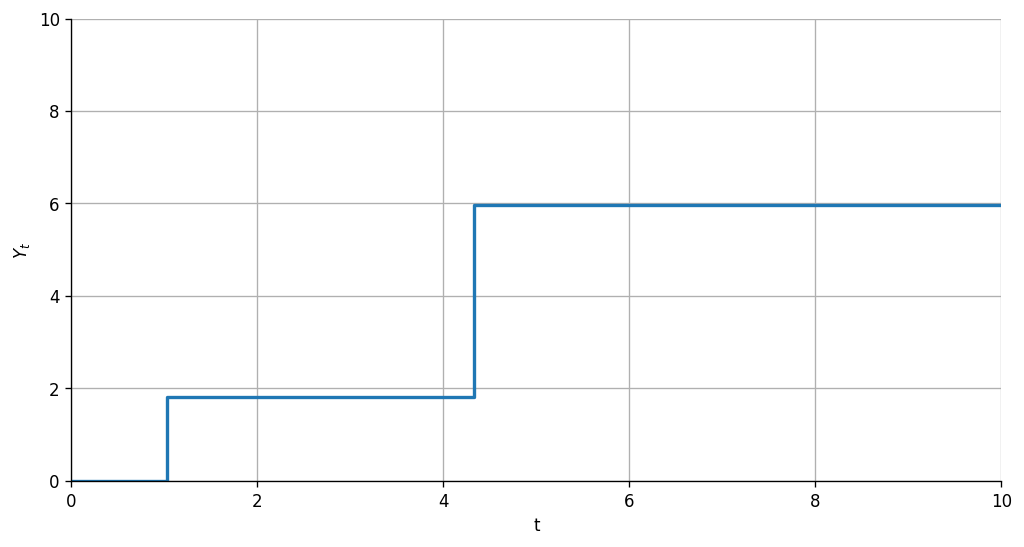

In [11]:
N = 50
rate = 0.5
T = 10

jump_times = np.cumsum(rng.exponential(scale=1 / rate, size=N))
jump_sizes = rng.exponential(scale=1 / rate, size=N)
process_values = np.cumsum(np.r_[0, jump_sizes])

plot_times = np.r_[0, jump_times]

fig, ax = plt.subplots()
ax.step(plot_times, process_values, where="post", color="tab:blue", linewidth=2)
ax.set_xlim(0, T)
ax.set_ylim(0, 10)
ax.set_xlabel("t")
ax.set_ylabel(r"$Y_t$")
plt.show()

### Listing 3.14. Compound Poisson with Gaussian jumps

이번에는 점프 크기 `Z_k`를 normal distribution에서 생성합니다. 점프 크기가 음수도 될 수 있으므로 process가 위아래로 움직일 수 있습니다.

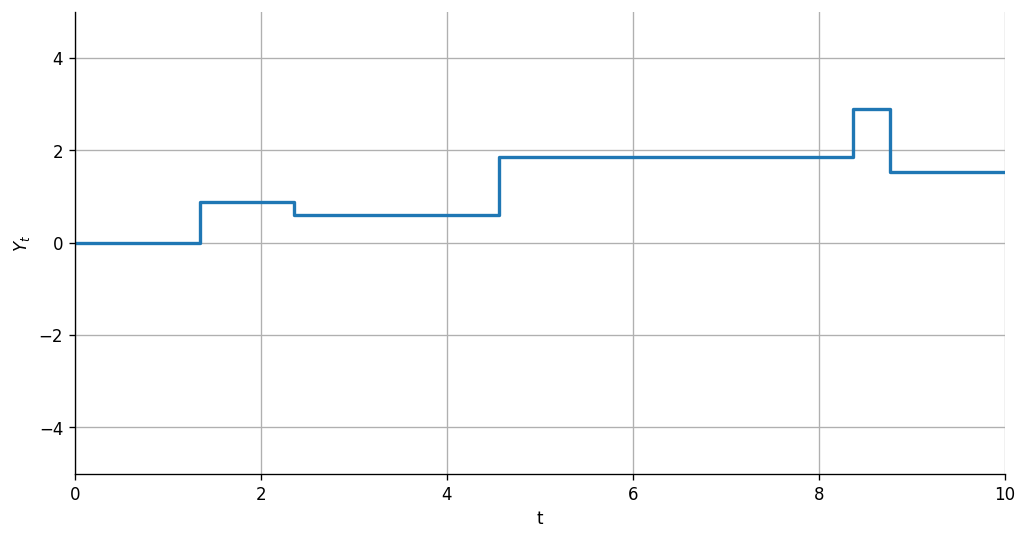

In [13]:
N = 50
rate = 0.5
T = 10

jump_times = np.cumsum(rng.exponential(scale=1 / rate, size=N))
jump_sizes = rng.normal(loc=0, scale=1, size=N)
process_values = np.cumsum(np.r_[0, jump_sizes])

plot_times = np.r_[0, jump_times]

fig, ax = plt.subplots()
ax.step(plot_times, process_values, where="post", color="tab:blue", linewidth=2)
ax.set_xlim(0, T)
ax.set_ylim(-5, 5)
ax.set_xlabel("t")
ax.set_ylabel(r"$Y_t$")
plt.show()

### Listing 3.16. Compensated compound Poisson process

Compound Poisson process의 평균 추세는 `lambda * t * E[Z]`입니다. 이를 제거한 `Y_t - lambda * t * E[Z]`가 compensated compound Poisson process입니다. 아래 예시에서는 점프 크기가 exponential distribution이고 평균이 `1 / lambda`라서 보정항은 `t`가 됩니다.

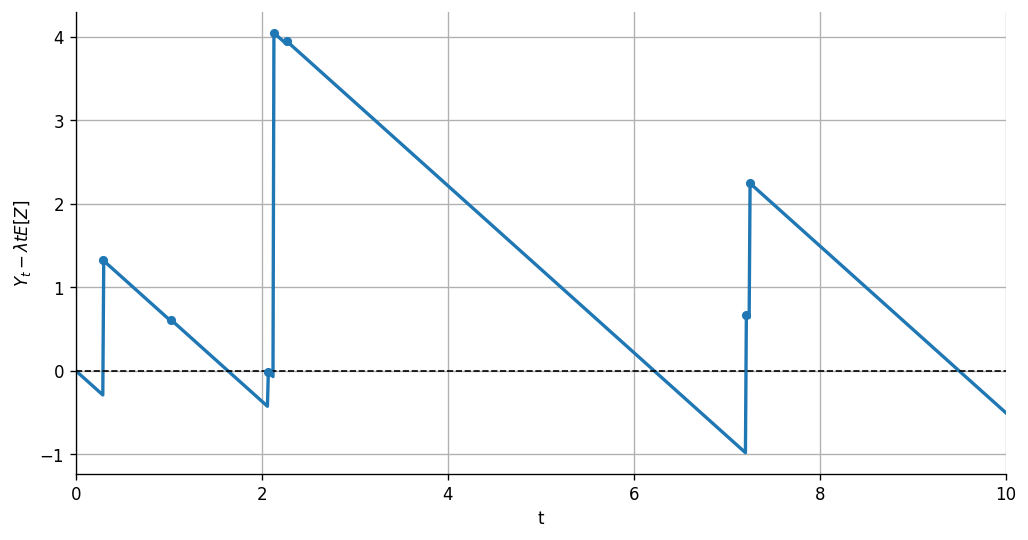

In [14]:
lam = 0.6
T = 10
jump_mean = 1 / lam

# T까지 필요한 점프를 interarrival time으로 생성합니다.
jump_times_list = []
current_time = 0.0
while current_time < T:
    current_time += rng.exponential(scale=1 / lam)
    if current_time <= T:
        jump_times_list.append(current_time)

jump_times = np.array(jump_times_list)
jump_sizes = rng.exponential(scale=jump_mean, size=len(jump_times))
cumulative_jumps = np.cumsum(jump_sizes)

t = np.linspace(0, T, 1_001)
N_t = np.searchsorted(jump_times, t, side="right")
Y_t = np.zeros_like(t)
positive_counts = N_t > 0
Y_t[positive_counts] = cumulative_jumps[N_t[positive_counts] - 1]

compensated = Y_t - lam * t * jump_mean
jump_levels = cumulative_jumps - lam * jump_times * jump_mean

fig, ax = plt.subplots()
ax.plot(t, compensated, color="tab:blue", linewidth=2)
ax.scatter(jump_times, jump_levels, color="tab:blue", s=20, zorder=3)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, T)
ax.set_xlabel("t")
ax.set_ylabel(r"$Y_t - \lambda t E[Z]$")
plt.show()

## 3.3 Claim and Reserve Processes

Reserve process는 보험사의 초기 준비금 `x`, 보험료 수입률 `c`, 누적 청구액을 함께 반영합니다.

\[
R_x(t) = x + ct - \sum_{k=1}^{N_t} Z_k
\]

`R_x(t)`가 0 아래로 내려가면 ruin이 발생한 것으로 봅니다.

### Listing 3.18. Simulation of ruin probability

원문의 코드는 여러 reserve path를 애니메이션처럼 그리며 ruin 확률을 추정합니다. 노트북에서는 같은 모형을 함수로 정리하고, 일부 경로를 한 그림에 표시한 뒤 simulation estimate와 이론적인 infinite-horizon ruin probability를 함께 출력합니다.

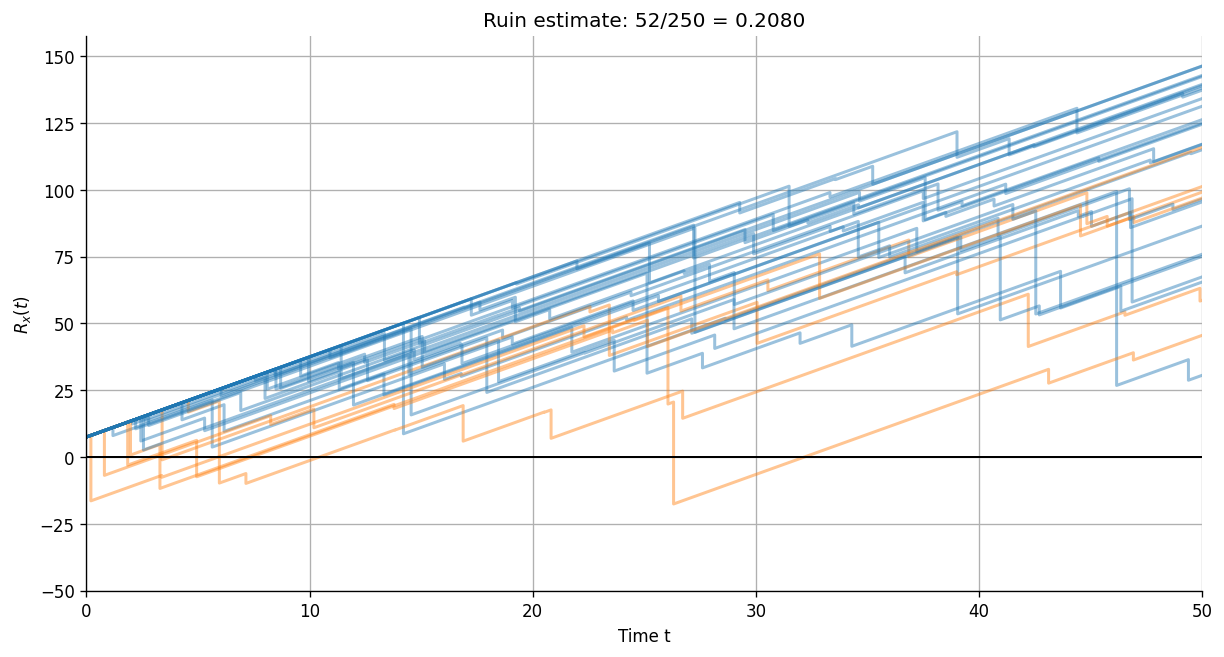

Simulation estimate over T=50: 0.2080 (52/250)
Theoretical infinite-horizon ruin probability: 0.2022


In [10]:
def simulate_reserve_path(T, lam, initial_reserve, mean_claim, premium_rate, rng):
    claim_times = []
    current_time = 0.0

    while current_time < T:
        current_time += rng.exponential(scale=1 / lam)
        if current_time < T:
            claim_times.append(current_time)

    claim_times = np.array(claim_times)
    claim_sizes = rng.exponential(scale=mean_claim, size=len(claim_times))

    path_times = [0.0]
    path_reserves = [initial_reserve]
    cumulative_claims = 0.0
    ruin_time = None

    for claim_time, claim_size in zip(claim_times, claim_sizes):
        reserve_before_claim = initial_reserve + premium_rate * claim_time - cumulative_claims
        reserve_after_claim = reserve_before_claim - claim_size

        path_times.extend([claim_time, claim_time])
        path_reserves.extend([reserve_before_claim, reserve_after_claim])

        cumulative_claims += claim_size
        if ruin_time is None and reserve_after_claim < 0:
            ruin_time = claim_time

    path_times.append(T)
    path_reserves.append(initial_reserve + premium_rate * T - cumulative_claims)

    return np.array(path_times), np.array(path_reserves), ruin_time


T = 50
n_sim = 250
lam = 0.1
initial_reserve = 7.5
mean_claim = 10
premium_rate = 3

ruin_count = 0
sample_paths = []

for k in range(n_sim):
    path_times, path_reserves, ruin_time = simulate_reserve_path(
        T=T,
        lam=lam,
        initial_reserve=initial_reserve,
        mean_claim=mean_claim,
        premium_rate=premium_rate,
        rng=rng,
    )
    ruined = ruin_time is not None
    ruin_count += int(ruined)

    if k < 30:
        sample_paths.append((path_times, path_reserves, ruined))

simulation_estimate = ruin_count / n_sim
theoretical_probability = (lam * mean_claim / premium_rate) * np.exp(
    -initial_reserve * (1 / mean_claim - lam / premium_rate)
)

fig, ax = plt.subplots(figsize=(12, 6))
for path_times, path_reserves, ruined in sample_paths:
    color = "tab:orange" if ruined else "tab:blue"
    ax.plot(path_times, path_reserves, color=color, alpha=0.45, linewidth=1.8)

ax.axhline(0, color="black", linewidth=1.2)
ax.set_xlim(0, T)
ax.set_ylim(-premium_rate * T / 3, initial_reserve + premium_rate * T)
ax.set_xlabel("Time t")
ax.set_ylabel(r"$R_x(t)$")
ax.set_title(f"Ruin estimate: {ruin_count}/{n_sim} = {simulation_estimate:.4f}")
plt.show()

print(f"Simulation estimate over T={T}: {simulation_estimate:.4f} ({ruin_count}/{n_sim})")
print(f"Theoretical infinite-horizon ruin probability: {theoretical_probability:.4f}")

## 정리

Chapter 3의 Python Listing들은 모두 점프가 있는 stochastic process를 시뮬레이션하는 데 초점이 있습니다.

- Poisson process: 사건의 발생 횟수를 세는 기본 counting process
- Compensated Poisson process: 평균 증가분을 제거한 mean-zero 형태
- Compound Poisson process: 각 사건의 크기를 더한 누적 손실 process
- Compensated compound Poisson process: 누적 손실의 평균 추세를 제거한 형태
- Reserve process: 보험사의 준비금이 청구 발생에 따라 어떻게 변하고 ruin이 발생하는지 보는 모형